# Track-wise dataset — 0.0625°, 30-minute, 1-minute decisions

Revamp of the tessellation notebook for the **CPR-gating RL problem**: MSI features →
decide whether to power up the CPR → scored afterwards against precipitation.

### What changed

| | tessellation notebook | this notebook |
|---|---|---|
| collection | `tavg01hr_2d_met3_Cx` @ 0.5° | `inst30mn_2d_met1_Nx` @ **0.0625°** |
| cadence | 1 hour | **30 min** (2× the distinct states) |
| decision interval | 10 min (~4,080 km) | **1 min (~408 km)** |
| grid built | global, 61.8 M cell-hours | **none — track-local only** |
| output | multi-GB parquet + 3.5 GB GeoJSON | **one row per decision (~2 MB / week)** |
| label geometry | max over swath (unresolvable at 2.5°) | **swath *and* nadir, both recorded** |

### Why the architecture had to change

One 0.0625° field is 2881 × 5760 = 16.6 M cells = **66.4 MB per variable per timestep**.
Eight months × 30-min × 15 variables is **~12 TB** globally. No chunking or striding
rescues that.

The fix is to stop building a grid. The agent only ever sees what the satellite flies
over, so we extract a small bounding slab around each short track segment, reduce it to
one row, and throw the array away. Peak memory is a single ~0.5 MB slab regardless of
how long the run is.

At 0.0625° the swath is finally resolvable — 150 km spans **21.6 cells** versus 0.54 at
2.5° — so a nadir-track label is meaningful here for the first time. Both are recorded
so the choice stays an experiment rather than an assumption.

> **This notebook and `extract_trackwise.py` share one configuration.**
> The long run is executed by the script (detached, `nohup`), because a 48-hour
> job should not depend on a Jupyter kernel surviving sleep and restarts:
>
> ```
> nohup python3 extract_trackwise.py > extract_8mo.log 2>&1 &
> ```
>
> Both write to `cache_8mo_jun2005/`. Run cells 1-5 here to inspect the setup,
> then skip the fetch cell and go straight to the loader/analysis cells once
> the script has written parts. **If you change the config in one file, change
> it in the other** — they were briefly out of sync.


In [ ]:
%pip install tatc pyarrow

from datetime import datetime, timezone, timedelta
import os, gc, time as _time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- configuration -------------------------------------------------------
# ---- WEATHER WINDOW ----
# 8 months starting at the wettest point of the G5NR record. June-July 2005 is
# the wettest consecutive 2-month window (area-weighted global mean prectot from
# tavg01mo_2d_met3_Cx: 3.204 mm/day, highest of all 24 months), so a June start
# opens on peak monsoon/ITCZ and sweeps through NH autumn into winter, giving
# real seasonal spread instead of a single regime.
# The G5NR 30-min axis starts 2005-05-15 21:30, hence the offset:
FIELD_START = 773           # G5NR step of 2005-06-01 00:00
N_FIELDS    = 11760         # 245 days -> 2006-02-01 00:00 (exclusive)
DECISION    = timedelta(minutes=1)    # the CPR on/off decision interval
SUB_STEP    = timedelta(seconds=1)    # 1 s ~= 6.8 km ~= one 0.0625 deg cell:
                                      # gives a CONTIGUOUS nadir track
G5_STEP     = timedelta(minutes=30)   # G5NR native cadence

# Measured against NCCS (see the concurrency cell below):
#   * ~1.0 s per VARIABLE of latency -> a 13-var request costs ~14 s regardless of size
#   * ~0.058 MB/s PER CONNECTION -> big bboxes are ruinous (98 MB took 380 s), so
#     keep GROUP small; 10 small requests beat 1 large one by 2.6x
#   * per-request time is FLAT as connections are added (13.7 / 13.8 / 14.1 s at
#     1 / 3 / 6 workers) -> the cap is per-connection, so concurrency scales ~linearly
# Therefore the run time is (requests x 14 s) / WORKERS, and full 1-minute sampling
# is feasible given enough concurrency. No decision sampling is required.
DEC_PER_FIELD = 30          # 30 = EVERY 1-minute decision (no sampling)
GROUP         = 3           # decisions per request; keep small (bbox hugs the track)
WORKERS       = 18          # PROCESSES. Threads do NOT help (netCDF-C serialises).
                            # Measured on this M4/16GB box (aggregate MB/s vs serial):
                            #   6 -> 5.3x | 12 -> 9.4x | 24 -> 12.8x
                            # Scaling is near-linear to ~12 then flattens (NCCS
                            # appears to shape per source IP). 18 workers ~= 11.3x
                            # and ~2.6 GB RSS (142 MB each). On a cluster, more
                            # NODES (distinct IPs) beat more processes on one host.
PAUSE         = 0.0
CACHE         = "cache_8mo_jun2005"
CHECKPOINT    = 200         # fields per parquet part

G5NR_URL = ("https://opendap.nccs.nasa.gov/dods/OSSE/G5NR/Ganymed/7km/"
            "0.0625_deg/inst/inst30mn_2d_met1_Nx")

# MSI-observable -> may enter the agent's observation vector
MSI = ["tautot", "tauhgh", "taulow", "cldtot", "cldhgh", "cldmid",
       "cldlow", "cldtmp", "lwtup"]
# CPR / ground truth -> label only, NEVER a feature.
# `cape` dropped: 20-30% fill, never used as a feature, and ~1 s on every request
# (~3 h over the run). `precsno` dropped for the same reason.
LAB = ["prectot", "preccon", "iwp", "lwp"]
VARS = MSI + LAB
assert not (set(MSI) & set(LAB)), "a variable cannot be both feature and label"

startdate = datetime(2025, 7, 19, 15, 4, tzinfo=timezone.utc)   # ground-track clock
N_ROWS    = N_FIELDS * DEC_PER_FIELD

# decision indices actually sampled: DEC_PER_FIELD consecutive minutes per field
PER_FIELD = int(G5_STEP / DECISION)          # 30 decisions exist per field
DEC_PER_FIELD = min(DEC_PER_FIELD, PER_FIELD)
SAMPLED = np.array([f * PER_FIELD + k
                    for f in range(N_FIELDS) for k in range(DEC_PER_FIELD)])
N_REQ = int(np.ceil(len(SAMPLED) / GROUP))

_per_req = len(VARS) * 1.0 + 0.94 * len(VARS) / 15 / 0.27      # latency + transfer
N_ROWS = len(SAMPLED)
print(f"Jun 2005 - Jan 2006 | {N_FIELDS:,} weather fields x {DEC_PER_FIELD} "
      f"decisions = {N_ROWS:,} rows")
print(f"{len(VARS)} vars ({len(MSI)} features + {len(LAB)} labels)")
print(f"{N_REQ:,} requests x ~{_per_req:.0f}s = {N_REQ*_per_req/3600:.0f} h serial")
# Estimate from MEASURED BLOCK TIMES, not from a burst benchmark. Short bursts
# suggested 5.9 s/task (=> 194 h for 8 months); the real 2-month run averaged
# 18-31 min per 200-field block at 18 workers (~24 min), i.e. ~24 h for 8 months.
# Burst benchmarks on a throttled server proved unreliable in BOTH directions.
_BLOCK_MIN = 24
_nblocks = -(-N_FIELDS // CHECKPOINT)
print(f"    {_nblocks} blocks x ~{_BLOCK_MIN} min (measured) = "
      f"{_nblocks*_BLOCK_MIN/60:.0f} h ({_nblocks*_BLOCK_MIN/1440:.1f} days)")
print(f"    worker RSS ~142 MB -> ~{WORKERS*0.142:.1f} GB total")
print(f"output ~{N_ROWS*25*8/1e6:.0f} MB | peak memory ~1 MB per worker (one slab)")


In [2]:
from tatc import utils
from tatc.schemas import PointedInstrument, Satellite, TwoLineElements

earthcare = Satellite(
    name="EarthCare",
    orbit=TwoLineElements(tle=[
        "1 59908U 24101A   25200.34125573  .00010433  00000+0  14571-3 0  9999",
        "2 59908  97.0168 326.4971 0001222 108.6708 251.4681 15.57041891 64775",
    ]),
    instruments=[PointedInstrument(
        name="MSI",
        field_of_regard=utils.swath_width_to_field_of_regard(394e3, 150e3) + 2 * 5.760868,
        cross_track_field_of_view=utils.swath_width_to_field_of_view(394e3, 150e3, 5.760868),
        along_track_field_of_view=utils.swath_width_to_field_of_view(394e3, 10e3, 5.760868),
        roll_angle=5.760868, is_rectangular=True)],
)
satellites = [earthcare]


In [3]:
import xarray as xr

# HTTP.TIMEOUT turns a stalled DAP transfer into a catchable exception
_dodsrc = os.path.expanduser("~/.dodsrc")
if not (os.path.exists(_dodsrc) and "HTTP.TIMEOUT" in open(_dodsrc).read()):
    with open(_dodsrc, "a") as f:
        f.write("HTTP.TIMEOUT=300\n")
    print("added HTTP.TIMEOUT=300 to ~/.dodsrc (restart kernel if DAP already used)")

def open_g5nr():
    for a in range(5):
        try:
            return xr.open_dataset(G5NR_URL, decode_times=True)
        except Exception as e:
            print(f"open failed {a+1}/5: {e}", flush=True)
            _time.sleep(15 * (a + 1))
    raise RuntimeError("could not open G5NR")

dataset = open_g5nr()
g5_times = pd.to_datetime(dataset["time"].values)
g5_lat = dataset["lat"].values
g5_lon = dataset["lon"].values
print(f"{G5NR_URL.rsplit('/',1)[-1]}: {len(g5_times):,} steps, "
      f"{g5_times[0]} -> {g5_times[-1]}")
print(f"grid {len(g5_lat)} x {len(g5_lon)}  (dlat {abs(g5_lat[1]-g5_lat[0]):.4f}°)")
missing = [v for v in VARS if v not in dataset.variables]
assert not missing, f"not in this collection: {missing}"
print(f"all {len(VARS)} requested variables present")


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xarray/coding/times.py:213: SerializationWarning: Ambiguous reference date string: 1-1-1 00:00:0.0. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 00:00:0.0). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  ref_date = _ensure_padded_year(ref_date)


inst30mn_2d_met1_Nx: 36,576 steps, 2005-05-15 21:30:00 -> 2007-06-16 21:00:00
grid 2881 x 5760  (dlat 0.0625°)
all 15 requested variables present


In [ ]:
from tatc.analysis import compute_ground_track
from joblib import Parallel, delayed
from skyfield.api import EarthSatellite, wgs84
from tatc.constants import timescale

SUB_PER_DEC = int(DECISION / SUB_STEP)

# footprints ONLY for the sampled decisions (not all 349,920)
def one_decision(i):
    t0 = startdate + int(i) * DECISION
    return compute_ground_track(
        satellites[0],
        pd.date_range(t0, t0 + DECISION, freq=SUB_STEP, inclusive="left"),
        crs="spice")

_t0 = _time.time()
tracks = pd.concat(Parallel(-1)(delayed(one_decision)(i) for i in SAMPLED),
                   ignore_index=True)
tracks["decision"] = SAMPLED
tracks["field"] = SAMPLED // PER_FIELD
_g = tracks.geometry.iloc[0]
print(f"{len(tracks):,} sampled footprints in {_time.time()-_t0:.0f}s "
      f"({_g.geom_type})")

# nadir sub-satellite points for those decisions only
_t0 = _time.time()
_sf = EarthSatellite(satellites[0].orbit.tle[0], satellites[0].orbit.tle[1],
                     "EarthCare", timescale)
_off = np.arange(SUB_PER_DEC) * SUB_STEP.total_seconds()
_secs = (SAMPLED[:, None] * DECISION.total_seconds() + _off[None, :]).ravel()
_ts = timescale.from_datetimes(
    pd.to_datetime(startdate) + pd.to_timedelta(_secs, unit="s"))
_sp = wgs84.subpoint(_sf.at(_ts))
nad_lat = _sp.latitude.degrees.astype("float32").reshape(len(SAMPLED), SUB_PER_DEC)
nad_lon = _sp.longitude.degrees.astype("float32").reshape(len(SAMPLED), SUB_PER_DEC)
del _sp, _ts, _secs; gc.collect()
_d = np.hypot(np.diff(nad_lat[0]) * 111.32,
              np.diff(nad_lon[0]) * 111.32 * np.cos(np.radians(nad_lat[0][:-1])))
print(f"nadir: {nad_lat.size:,} points in {_time.time()-_t0:.0f}s "
      f"({nad_lat.nbytes*2/1e6:.0f} MB) | spacing {_d.mean():.2f} km "
      f"-> {'contiguous' if _d.mean() <= 1.5*0.0625*111.32 else 'GAPS'}")

# decision -> row index in nad_lat/nad_lon
ROW_OF = {int(d): i for i, d in enumerate(SAMPLED)}


## Streaming extraction

For each group of `GROUP` consecutive decisions:

1. take the union bounding box (consecutive 1-minute segments are nearly collinear, so
   the box hugs the track — this is why `GROUP` is small)
2. fetch that slab for the nearest 30-minute timestep
3. reduce each decision to **one row**: MSI features averaged over the swath, labels taken
   as the peak over the swath *and* separately over the nadir track
4. free the slab

Nothing global is ever materialised, so memory is flat in the length of the run. Parts are
checkpointed to parquet, so a rerun resumes.

In [ ]:
import shapely
from joblib import Parallel, delayed

os.makedirs(CACHE, exist_ok=True)

# Field f maps to G5NR time index f exactly (one field == one 30-min step), so the
# time mapping is pure index arithmetic. NEVER match datetimes: ground-track times
# are on a 2025 TLE clock and the G5NR axis is 2005-2007, so nearest-datetime
# collapses every request onto the last step (that bug produced a 1-field dataset).
assert FIELD_START + N_FIELDS <= len(g5_times), "window exceeds the G5NR axis"
print(f"time map: field 0..{N_FIELDS-1} -> G5NR steps "
      f"{FIELD_START}..{FIELD_START+N_FIELDS-1} = "
      f"{g5_times[FIELD_START]} .. {g5_times[FIELD_START+N_FIELDS-1]}")

_WDS = None
def _wds(force=False):
    """One DAP handle per worker, reused; `force` discards a dead one.

    The reset MUST go through this function's own `global _WDS`. An earlier
    version did `globals()["_WDS"] = None` from inside process_field; under
    cloudpickle that resolves to a different namespace, so the reset silently
    did nothing -- a worker whose handle died (laptop sleep) kept handing back
    that dead handle and every later task timed out. Cost: 18 workers, 10 hours,
    zero rows, against a perfectly healthy server.
    """
    global _WDS
    if force and _WDS is not None:
        try:
            _WDS.close()
        except Exception:
            pass
        _WDS = None
    if _WDS is None:
        import xarray as xr
        _WDS = xr.open_dataset(G5NR_URL, decode_times=True)
    return _WDS

def _nanmax(a):
    a = a[np.isfinite(a)]
    return float(a.max()) if a.size else float("nan")

def _nanmean(a):
    a = a[np.isfinite(a)]
    return float(a.mean()) if a.size else float("nan")

def reduce_decision(geom, sub, nlat, nlon):
    la = sub["lat"].values; lo = sub["lon"].values
    if la.size == 0 or lo.size == 0:
        return None
    LO, LA = np.meshgrid(lo, la)
    inside = shapely.contains_xy(geom, LO, LA)
    if not inside.any():
        c = geom.centroid
        inside = np.zeros_like(LO, dtype=bool)
        inside[np.abs(la - c.y).argmin(), np.abs(lo - c.x).argmin()] = True
    keep = ((nlat >= la.min()) & (nlat <= la.max())
            & (nlon >= lo.min()) & (nlon <= lo.max()))
    if not keep.any():
        keep = np.ones_like(nlat, dtype=bool)
    ni = np.abs(la[:, None] - nlat[keep][None, :]).argmin(axis=0)
    nj = np.abs(lo[:, None] - nlon[keep][None, :]).argmin(axis=0)
    row = {}
    for v in MSI:
        row[f"{v}_mean"] = _nanmean(sub[v].values[inside])
    row["tautot_max"] = _nanmax(sub["tautot"].values[inside])
    for v in LAB:
        arr = sub[v].values
        row[f"{v}_swath"] = _nanmax(arr[inside])
        row[f"{v}_nadir"] = _nanmax(arr[ni, nj])
    row["n_swath_cells"] = int(inside.sum())
    row["n_nadir_cells"] = len(set(zip(ni, nj)))
    return row

def process_field(fi, geoms, decs, times, nlats, nlons):
    """One 30-min field -> rows. Runs in a worker process.
    `fi` is the RELATIVE field index; absolute G5NR time index = FIELD_START + fi."""
    import xarray as xr
    g5i = FIELD_START + fi
    pad = 0.13
    xs = [g.bounds for g in geoms]
    lat0 = min(b[1] for b in xs); lat1 = max(b[3] for b in xs)
    lon0 = min(b[0] for b in xs); lon1 = max(b[2] for b in xs)
    sub = None
    for a in range(4):
        try:
            ds = _wds(force=(a > 0))   # retries always get a FRESH handle
            sel = dict(lat=slice(lat0 - pad, lat1 + pad))
            if lon1 - lon0 > 180:
                w = ds[VARS].isel(time=g5i).sel(lon=slice(120, 180), **sel).load()
                e = ds[VARS].isel(time=g5i).sel(lon=slice(-180, -120), **sel).load()
                sub = xr.concat([w, e], dim="lon")
            else:
                sub = ds[VARS].isel(time=g5i).sel(
                    lon=slice(lon0 - pad, lon1 + pad), **sel).load()
            break
        except Exception:
            _time.sleep(min(4 * 2 ** a, 45))
    if sub is None:
        return []
    out = []
    for g, d, t, nla, nlo in zip(geoms, decs, times, nlats, nlons):
        r = reduce_decision(g, sub, nla, nlo)
        if r is None:
            continue
        r.update(decision=int(d), field=int(fi), g5_step=int(g5i),
                 time=t, lat=g.centroid.y, lon=g.centroid.x)
        out.append(r)
    return out

# One TASK = up to GROUP consecutive decisions inside one field. They share the
# field's G5NR step, and a short segment keeps the bbox tight around the track.
by_field = {f: g for f, g in tracks.groupby("field")}
blocks = [(b, min(b + CHECKPOINT, N_FIELDS)) for b in range(0, N_FIELDS, CHECKPOINT)]
todo = [(a, b) for a, b in blocks
        if not os.path.exists(f"{CACHE}/rows_{a//CHECKPOINT:05d}.parquet")]
print(f"{len(blocks)} blocks | {len(blocks)-len(todo)} cached | {len(todo)} to fetch")
print(f"{N_REQ:,} requests total, {WORKERS} concurrent")

_t0 = _time.time()
for a, b in todo:
    args = []
    for fi in range(a, b):
        seg = by_field.get(fi)
        if seg is None or len(seg) == 0:
            continue
        seg = seg.sort_values("decision")
        for s in range(0, len(seg), GROUP):          # split field into small bboxes
            ch = seg.iloc[s:s + GROUP]
            rows_i = [ROW_OF[int(d)] for d in ch.decision]
            args.append((fi, list(ch.geometry), list(ch.decision), list(ch.time),
                         [nad_lat[i] for i in rows_i], [nad_lon[i] for i in rows_i]))
    res = Parallel(n_jobs=WORKERS, backend="loky", verbose=0)(
        delayed(process_field)(*x) for x in args)
    flat = [r for rs in res for r in rs]
    if flat:
        pd.DataFrame(flat).to_parquet(
            f"{CACHE}/rows_{a//CHECKPOINT:05d}.parquet", index=False)
    el = _time.time() - _t0
    dn = (a - todo[0][0]) // CHECKPOINT + 1
    print(f"  block {a//CHECKPOINT}: {len(flat):,} rows | {el/60:.0f} min "
          f"| eta {el/dn*(len(todo)-dn)/3600:.1f} h", flush=True)
    del res, flat; gc.collect()
print(f"\ndone in {(_time.time()-_t0)/3600:.1f} h")


In [ ]:
import glob
rows = pd.concat((pd.read_parquet(f) for f in sorted(glob.glob(f"{CACHE}/rows_*.parquet"))),
                 ignore_index=True)
rows["solar_hour"] = ((rows.time.dt.hour + rows.time.dt.minute / 60
                       + rows.lon / 15) % 24)
print(f"{len(rows):,} decision rows x {rows.shape[1]} cols")
_nf = rows.field.nunique()
print(f"distinct G5NR weather fields: {_nf}  ({len(rows)/_nf:.0f} decisions each)")
assert _nf > 1, "only one weather field — the time mapping is broken"
print(f"swath cells/decision: mean {rows.n_swath_cells.mean():.0f} "
      f"| nadir {rows.n_nadir_cells.mean():.1f}")
rows.to_parquet("trackwise_decisions.parquet", index=False)
print(f"saved trackwise_decisions.parquet "
      f"({os.path.getsize('trackwise_decisions.parquet')/1e6:.1f} MB)")
rows.head()


In [7]:
# ---- CLASS BALANCE: swath label vs nadir label, across thresholds ----
MM = 3600.0     # kg m-2 s-1 -> mm/hr
print(f"{len(rows):,} decisions ({DECISION.total_seconds()/60:.0f}-minute interval)\n")
print(f"{'threshold':<20}{'prectot swath':>16}{'prectot nadir':>16}"
      f"{'preccon swath':>16}{'preccon nadir':>16}")
for nm, mm in [("any > 0", 0.0), (">= 0.1 mm/hr", 0.1), (">= 0.5 mm/hr", 0.5),
               (">= 1 mm/hr", 1.0), (">= 5 mm/hr", 5.0), (">= 10 mm/hr", 10.0)]:
    t = mm / MM
    cells = []
    for c in ["prectot_swath", "prectot_nadir", "preccon_swath", "preccon_nadir"]:
        p = 100 * (rows[c] > t).mean()
        cells.append(f"{int((rows[c] > t).sum()):>7,} ({p:4.1f}%)")
    print(f"  {nm:<18}" + "".join(f"{c:>16}" for c in cells))

print("\nA usable binary label sits near 50%. The nadir column is what the CPR would")
print("actually measure; the swath column credits it with precipitation it never flies over.")
for c in ["prectot_swath", "prectot_nadir"]:
    r = (rows[c] > 1.0 / MM).mean()
    print(f"  {c:<15} at >=1 mm/hr: {100*r:.1f}% positive")


10,080 decisions (1-minute interval)

threshold              prectot swath   prectot nadir   preccon swath   preccon nadir
  any > 0              9,894 (98.2%)   9,813 (97.4%)   4,904 (48.7%)   4,060 (40.3%)
  >= 0.1 mm/hr         6,699 (66.5%)   4,921 (48.8%)   2,408 (23.9%)   1,595 (15.8%)
  >= 0.5 mm/hr         4,344 (43.1%)   2,326 (23.1%)     996 ( 9.9%)     334 ( 3.3%)
  >= 1 mm/hr           3,198 (31.7%)   1,495 (14.8%)     513 ( 5.1%)     124 ( 1.2%)
  >= 5 mm/hr           1,344 (13.3%)     443 ( 4.4%)     217 ( 2.2%)      26 ( 0.3%)
  >= 10 mm/hr            871 ( 8.6%)     233 ( 2.3%)     113 ( 1.1%)      11 ( 0.1%)

A usable binary label sits near 50%. The nadir column is what the CPR would
actually measure; the swath column credits it with precipitation it never flies over.
  prectot_swath   at >=1 mm/hr: 31.7% positive
  prectot_nadir   at >=1 mm/hr: 14.8% positive


In [8]:
# ---- learnability: do MSI-observable features separate the classes? ----
def auc(score, y):
    m = np.isfinite(score); s, yy = np.asarray(score)[m], np.asarray(y)[m]
    if yy.sum() in (0, len(yy)): return float("nan")
    r = pd.Series(s).rank().values
    npos = yy.sum(); return (r[yy == 1].sum() - npos*(npos+1)/2) / (npos*(len(yy)-npos))

FEATS = [f"{v}_mean" for v in MSI] + ["tautot_max", "solar_hour"]
for lab in ["prectot_nadir", "prectot_swath"]:
    y = (rows[lab] > 1.0 / MM).astype(int).values
    print(f"\n=== label: {lab} >= 1 mm/hr   ({100*y.mean():.1f}% positive) ===")
    sk = sorted(((auc(rows[f].values.astype(float), y), f) for f in FEATS),
                key=lambda z: -abs((z[0] if np.isfinite(z[0]) else .5) - .5))
    for a, f in sk[:6]:
        print(f"  {f:<16}{a:6.3f}" + (f"   (inverted {1-a:.3f})" if a < 0.5 else ""))

try:
    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import roc_auc_score, average_precision_score
    X = rows[FEATS].replace([np.inf, -np.inf], np.nan)
    X = ((X - X.mean()) / X.std()).fillna(0).values
    y = (rows["prectot_nadir"] > 1.0 / MM).astype(int).values
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=.3, random_state=0, stratify=y)
    clf = LogisticRegression(max_iter=2000, class_weight="balanced").fit(Xtr, ytr)
    p = clf.predict_proba(Xte)[:, 1]
    print(f"\nlogistic on {len(FEATS)} MSI features -> nadir prectot >= 1 mm/hr")
    print(f"  ROC-AUC {roc_auc_score(yte,p):.3f} | avg-precision "
          f"{average_precision_score(yte,p):.3f} (base rate {yte.mean():.3f})")
except ImportError:
    print("\n(sklearn unavailable)")



=== label: prectot_nadir >= 1 mm/hr   (14.8% positive) ===
  tautot_mean      0.830
  tautot_max       0.794
  taulow_mean      0.739
  tauhgh_mean      0.734
  cldmid_mean      0.709
  cldtot_mean      0.650

=== label: prectot_swath >= 1 mm/hr   (31.7% positive) ===
  tautot_mean      0.847
  tautot_max       0.828
  taulow_mean      0.777
  tauhgh_mean      0.714
  cldmid_mean      0.658
  cldhgh_mean      0.597

logistic on 11 MSI features -> nadir prectot >= 1 mm/hr
  ROC-AUC 0.841 | avg-precision 0.435 (base rate 0.148)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linea

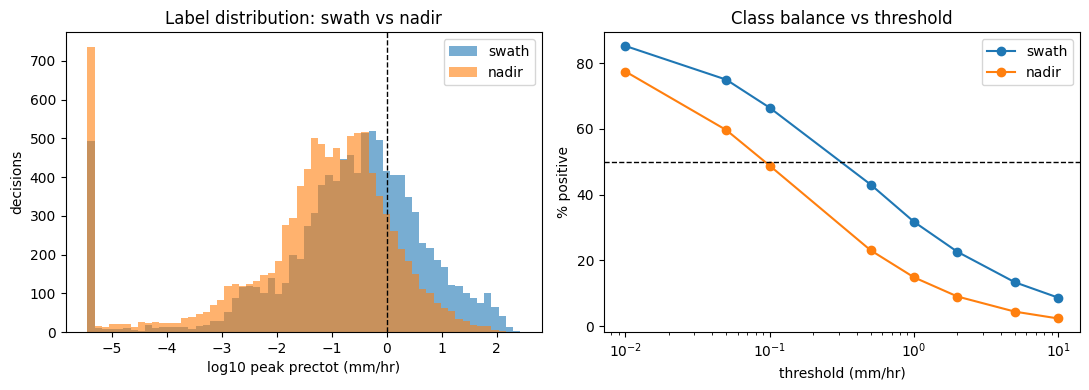

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
MM = 3600.0
ax[0].hist(np.log10(rows.prectot_swath.clip(lower=1e-9) * MM), bins=60,
           alpha=.6, label="swath")
ax[0].hist(np.log10(rows.prectot_nadir.clip(lower=1e-9) * MM), bins=60,
           alpha=.6, label="nadir")
ax[0].axvline(0, color="k", ls="--", lw=1)
ax[0].set_xlabel("log10 peak prectot (mm/hr)"); ax[0].set_ylabel("decisions")
ax[0].set_title("Label distribution: swath vs nadir"); ax[0].legend()

th = np.array([0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10])
for c, lb in [("prectot_swath", "swath"), ("prectot_nadir", "nadir")]:
    ax[1].plot(th, [100 * (rows[c] > t / MM).mean() for t in th], marker="o", label=lb)
ax[1].axhline(50, color="k", ls="--", lw=1)
ax[1].set_xscale("log"); ax[1].set_xlabel("threshold (mm/hr)")
ax[1].set_ylabel("% positive"); ax[1].set_title("Class balance vs threshold"); ax[1].legend()
plt.tight_layout(); plt.show()


## Visuals and exports\n\nRun these after the loader cell once `cache_junjul2005/` has parts.

In [ ]:
# ---- cartopy visuals (ports of the original notebook's figures) ----
%pip install seaborn cartopy
import seaborn as sns
import cartopy.crs as ccrs
import matplotlib.colors as mcolors

MM = 3600.0
THR = rows.prectot_nadir.quantile(0.50)      # balanced label for THIS window
print(f"balanced threshold: {THR*MM:.3f} mm/hr "
      f"({100*(rows.prectot_nadir>THR).mean():.1f}% positive)")
rows["fire"] = (rows.prectot_nadir > THR).astype(int)

# --- 1-2. KDE maps: precipitation, then cloud cover (originals 17-19) ---
for col, w, title in [
    ("prectot_nadir", None, "KDE of nadir precipitation seen by EarthCARE (Jun-Jul 2005)"),
    ("tautot_mean",   None, "KDE of MSI cloud optical thickness along track (Jun-Jul 2005)"),
]:
    d = rows[np.isfinite(rows[col]) & (rows[col] > 0)]
    fig, ax = plt.subplots(figsize=(11, 5), subplot_kw={"projection": ccrs.PlateCarree()})
    sns.kdeplot(data=d, x="lon", y="lat", weights=col, fill=True,
                cmap="turbo", bw_adjust=0.25, levels=14, ax=ax)
    ax.coastlines(linewidth=0.6); ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
    ax.set_title(title); ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.set_xticks(range(-180, 181, 30)); ax.set_yticks(range(-90, 91, 30))
    ax.gridlines(draw_labels=False, linewidth=0.3)
    plt.tight_layout(); plt.show()

# --- 3. decisions along track, coloured by the CPR decision (replaces the old
#        observed/unobserved cluster animation) ---
fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={"projection": ccrs.PlateCarree()})
sub = rows.iloc[::max(len(rows)//12000, 1)]          # thin for legibility
ax.scatter(sub.loc[sub.fire == 0, "lon"], sub.loc[sub.fire == 0, "lat"],
           s=1.5, c="#A50026", alpha=.45, transform=ccrs.PlateCarree(), label="CPR off")
ax.scatter(sub.loc[sub.fire == 1, "lon"], sub.loc[sub.fire == 1, "lat"],
           s=1.5, c="#006837", alpha=.65, transform=ccrs.PlateCarree(), label="CPR on")
ax.coastlines(linewidth=0.6); ax.set_global()
ax.set_title(f"1-minute CPR decisions along track "
             f"(green = nadir precip > {THR*MM:.2f} mm/hr)")
ax.gridlines(draw_labels=False, linewidth=0.3)
ax.legend(loc="lower left", markerscale=6, framealpha=.9)
plt.tight_layout(); plt.show()

# --- 4. precipitation vs solar hour (originals 15-16) ---
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
h = rows.assign(sh=rows.solar_hour.round()).groupby("sh").agg(
        m=("prectot_nadir", "mean"), p=("fire", "mean")).reset_index()
ax[0].plot(h.sh, h.m * MM, marker=".", color="b")
ax[0].set_xlabel("Solar Hour (0-23)"); ax[0].set_ylabel("mean nadir prectot (mm/hr)")
ax[0].set_title("Precipitation vs solar hour"); ax[0].set_xticks(range(0, 25, 3))
sns.kdeplot(data=rows, x="solar_hour", y=rows.prectot_nadir*MM, fill=True,
            cmap="Reds", bw_adjust=0.6, ax=ax[1])
ax[1].set_xlim(0, 23); ax[1].set_ylim(0, 5); ax[1].set_xticks(range(0, 25, 3))
ax[1].set_xlabel("Solar Hour (0-24)"); ax[1].set_ylabel("nadir prectot (mm/hr)")
ax[1].set_title("Density")
plt.tight_layout(); plt.show()

# --- 5. latitude bands (original 24) ---
band = pd.cut(rows.lat, [-90,-75,-45,-15,15,45,75,90],
              labels=["<-75","-75:-45","-45:-15","tropics","15:45","45:75",">75"],
              include_lowest=True)
rep = pd.DataFrame({"decisions": rows.groupby(band, observed=True).size(),
                    "CPR-on %": 100*rows.fire.groupby(band, observed=True).mean(),
                    "mean mm/hr": MM*rows.prectot_nadir.groupby(band, observed=True).mean()})
display(rep.round(2))
fig, ax = plt.subplots(figsize=(9, 3))
ax.hist(rows.loc[rows.fire==1, "lat"], bins=72, color="#006837", alpha=.8)
ax.set_xlabel("latitude"); ax.set_ylabel("CPR-on decisions")
ax.set_title("Where the agent should fire the CPR")
plt.tight_layout(); plt.show()


In [ ]:
# ---- exports ----------------------------------------------------------
# CZML is the deliverable here: Cesium needs TIME-DYNAMIC data to animate an
# orbit. (GeoJSON is static and cannot express "the satellite is here at t" —
# that is why it is not produced.) CSV is kept for kepler.gl / analysis.
import json as _json

MM  = 3600.0
ALT = 394_000.0            # EarthCARE mean altitude, metres
CZML_DAYS   = 3            # animate this many days; ~0.25 MB/day
BEAM_EVERY  = 1            # draw the CPR beam on every Nth firing decision

if "fire" not in rows.columns:
    THR = rows.prectot_nadir.quantile(0.50)
    rows["fire"] = (rows.prectot_nadir > THR).astype(int)
THR = rows.loc[rows.fire == 1, "prectot_nadir"].min()

# --- CSV (kepler.gl auto-detects lat/lon; far lighter than any geo format) ---
rows.to_csv("cpr_decisions_full.csv", index=False)
rows.iloc[::max(len(rows)//20000, 1)].to_csv("cpr_decisions_kepler.csv", index=False)

# --- CZML ---------------------------------------------------------------
t0  = rows.time.min()
seg = rows[rows.time < t0 + pd.Timedelta(days=CZML_DAYS)].sort_values("time")
epoch = t0.strftime("%Y-%m-%dT%H:%M:%SZ")
stop  = seg.time.max().strftime("%Y-%m-%dT%H:%M:%SZ")
iso   = lambda x: x.strftime("%Y-%m-%dT%H:%M:%SZ")

# satellite position samples: [seconds_since_epoch, lon, lat, alt, ...]
samples = []
for r in seg.itertuples():
    samples += [float((r.time - t0).total_seconds()),
                round(float(r.lon), 4), round(float(r.lat), 4), ALT]

czml = [
    {"id": "document", "name": "EarthCARE CPR gating (Jun-Jul 2005)", "version": "1.0",
     "clock": {"interval": f"{epoch}/{stop}", "currentTime": epoch,
               "multiplier": 300, "range": "LOOP_STOP",
               "step": "SYSTEM_CLOCK_MULTIPLIER"}},
    {"id": "earthcare", "name": "EarthCARE",
     "description": "MSI images continuously; the agent decides each minute "
                    "whether to power the CPR.",
     "availability": f"{epoch}/{stop}",
     "position": {"epoch": epoch, "cartographicDegrees": samples,
                  "interpolationAlgorithm": "LAGRANGE", "interpolationDegree": 5},
     "point": {"color": {"rgba": [255, 255, 255, 255]}, "pixelSize": 12,
               "outlineColor": {"rgba": [40, 40, 40, 255]}, "outlineWidth": 2},
     "label": {"text": "EarthCARE", "fillColor": {"rgba": [255, 255, 255, 220]},
               "font": "12pt sans-serif", "pixelOffset": {"cartesian2": [14, 0]},
               "horizontalOrigin": "LEFT", "scaleByDistance":
                   {"nearFarScalar": [1.5e6, 1.0, 1.5e7, 0.4]}},
     "path": {"material": {"polylineOutline": {
                  "color": {"rgba": [120, 190, 255, 200]},
                  "outlineColor": {"rgba": [0, 0, 0, 90]}, "outlineWidth": 1}},
              "width": 3, "leadTime": 0, "trailTime": 5400, "resolution": 60}},
]

# ground decisions + a nadir "beam" whenever the CPR fires
nfire = 0
for i, r in enumerate(seg.itertuples()):
    s, e = iso(r.time), iso(r.time + pd.Timedelta(minutes=25))
    czml.append({
        "id": f"d{int(r.decision)}", "availability": f"{s}/{e}",
        "position": {"cartographicDegrees": [float(r.lon), float(r.lat), 0.0]},
        "point": {"pixelSize": 7, "heightReference": "CLAMP_TO_GROUND",
                  "color": {"rgba": [0, 190, 80, 230] if r.fire
                            else [190, 40, 50, 130]}},
        "description": (f"<b>{iso(r.time)}</b><br>"
                        f"CPR: {'ON' if r.fire else 'off'}<br>"
                        f"nadir precip: {r.prectot_nadir*MM:.2f} mm/hr<br>"
                        f"tautot: {r.tautot_mean:.1f} | cloud: {r.cldtot_mean:.2f}")})
    if r.fire and (nfire := nfire + 1) % BEAM_EVERY == 0:
        czml.append({
            "id": f"beam{int(r.decision)}",
            "availability": f"{s}/{iso(r.time + pd.Timedelta(minutes=2))}",
            "polyline": {"positions": {"cartographicDegrees":
                             [float(r.lon), float(r.lat), ALT,
                              float(r.lon), float(r.lat), 0.0]},
                         "material": {"solidColor": {"color":
                             {"rgba": [0, 255, 140, 170]}}},
                         "width": 2, "arcType": "NONE"}})

with open("cpr_decisions.czml", "w") as f:
    _json.dump(czml, f)

for fn in ["cpr_decisions_full.csv", "cpr_decisions_kepler.csv", "cpr_decisions.czml"]:
    print(f"  {fn:<28}{os.path.getsize(fn)/1e6:7.2f} MB")
print(f"\nCZML: {CZML_DAYS} days, {len(seg):,} decisions, "
      f"{int(seg.fire.sum()):,} CPR firings, {len(czml):,} packets")
print(f"threshold {THR*MM:.3f} mm/hr | clock 300x real time "
      f"-> {CZML_DAYS*24*3600/300/60:.0f} min of playback")
print("\nView: https://sandcastle.cesium.com -> paste a viewer + "
      "Cesium.CzmlDataSource.load('cpr_decisions.czml'), or drag onto cesium.com/ion")
print("kepler.gl: drag cpr_decisions_kepler.csv onto https://kepler.gl/demo")
